# Chapter 19 -- Writing Small Mathematical Programs

> **Prerequisites:** ch001-ch018
>
> **You will learn:**
> - How to translate a mathematical specification into clean, verifiable code
> - The discipline of mathematical programming: correctness before efficiency
> - How to test mathematical code systematically with property-based testing
> - Numerical edge cases that trip up mathematical implementations
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Mathematical programming is writing code that correctly implements mathematical specifications. It differs from ordinary programming in the verification standard: a mathematical program must satisfy provable properties, not just pass test cases.

The discipline has three pillars:

**1. Specification first.** Before writing code, write the mathematical specification as a docstring: input type, output type, formula, edge cases, properties the output must satisfy.

**2. Property-based testing.** Instead of testing f(3)==9 (specific example), test f(n) == f(n-1) + 2*n - 1 for all n in range. Mathematical functions have algebraic properties testable universally.

**3. Numerical awareness.** Integer arithmetic is exact; floating-point is not. Mathematical programs must be explicit about which domain they operate in.

**Common misconception:** If it passes unit tests, it is correct.

Unit tests check specific examples. A mathematical program has algebraic properties that hold for infinite domains. Testing ten cases validates ten cases. Property testing builds much stronger evidence.

## 2. Intuition & Mental Models

**Physical analogy:** Calibrated instruments. A thermometer correct at 0C and 100C might be wrong everywhere in between. A function tested at specific values might fail at untested values if the implementation does not encode the mathematical structure. Property-based testing is calibration across the full range.

**Computational analogy:** Type systems. A well-typed function accepts only correct-type inputs regardless of value. Property-based testing is the runtime analog: it guarantees outputs satisfy mathematical properties regardless of input.

Recall from ch002 *(Mathematics vs Programming Thinking)*: property-based testing was introduced as the computational form of relational thinking. This chapter applies it systematically.

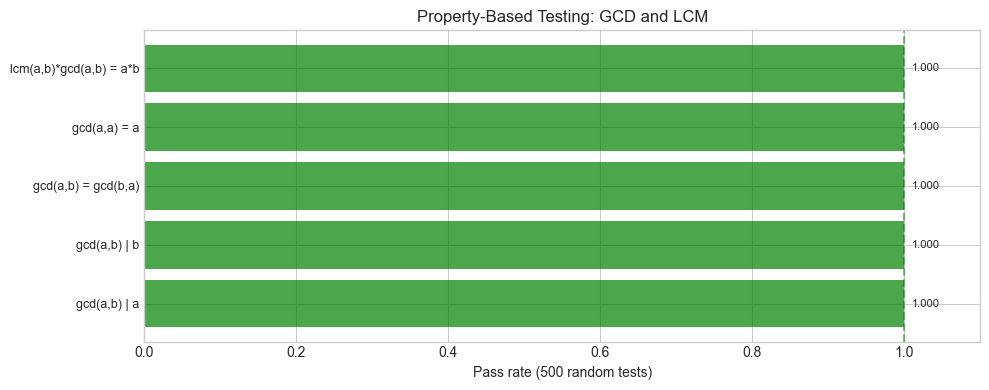

In [1]:
# --- Visualization: Property-based testing dashboard ---
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(42); np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

def gcd_euclid(a, b):
    a, b = abs(int(a)), abs(int(b))
    while b: a, b = b, a % b
    return a

def lcm(a, b):
    g = gcd_euclid(a, b)
    return (a * b) // g if g > 0 else 0

def is_prime(n):
    n = int(n)
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    return all(n % i != 0 for i in range(3, int(n**0.5)+1, 2))

properties = {
    'gcd(a,b) | a':              lambda a,b: a % gcd_euclid(a,b) == 0,
    'gcd(a,b) | b':              lambda a,b: b % gcd_euclid(a,b) == 0,
    'gcd(a,b) = gcd(b,a)':       lambda a,b: gcd_euclid(a,b) == gcd_euclid(b,a),
    'gcd(a,a) = a':              lambda a,b: gcd_euclid(a,a) == a,
    'lcm(a,b)*gcd(a,b) = a*b':  lambda a,b: lcm(a,b) * gcd_euclid(a,b) == a*b,
}

N_TESTS = 500
results = {}
for name, prop in properties.items():
    passes = sum(prop(random.randint(1,200), random.randint(1,200)) for _ in range(N_TESTS))
    results[name] = passes / N_TESTS

fig, ax = plt.subplots(figsize=(10, 4))
names = list(results.keys())
scores = [results[n] for n in names]
colors = ['green' if s == 1.0 else 'red' for s in scores]
bars = ax.barh(range(len(names)), scores, color=colors, alpha=0.7)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Pass rate (500 random tests)'); ax.set_xlim(0, 1.1)
ax.axvline(1.0, color='green', linestyle='--', alpha=0.5)
for bar, s in zip(bars, scores):
    ax.text(s+0.01, bar.get_y()+bar.get_height()/2, f'{s:.3f}', va='center', fontsize=8)
ax.set_title('Property-Based Testing: GCD and LCM')
plt.tight_layout(); plt.show()

## 4. Mathematical Formulation

**Mathematical specification format:**

  f: D -> R  where D = domain (valid inputs), R = range (valid outputs)

Properties of f that must hold:
- Correctness: f satisfies its defining equation on all x in D
- Boundary conditions: behavior at edge cases (0, 1, infinity, etc.)
- Algebraic identities: symmetry, associativity, distributivity

**Numerical precision hierarchy:**
1. Exact integer arithmetic -- no rounding error
2. Floating-point (float64) -- relative error ~2^-52 ~ 1e-16 (machine epsilon)
3. Accumulated floating-point -- error grows with number of operations

Mathematical implementations must operate in the appropriate precision class.

In [2]:
# --- Implementation: Small mathematical library ---
import numpy as np, math

def integer_sqrt(n):
    """
    Compute floor(sqrt(n)) for non-negative integer n using only integer arithmetic.
    
    Properties:
        k^2 <= n < (k+1)^2  where k = integer_sqrt(n)
        Exact for perfect squares
    """
    if n < 0: raise ValueError(f"integer_sqrt undefined for n={n}")
    if n == 0: return 0
    k = n
    while True:
        k_new = (k + n // k) // 2
        if k_new >= k: return k
        k = k_new

def binomial(n, k):
    """
    Compute C(n,k) exactly as an integer.
    
    Properties:
        C(n,0) = C(n,n) = 1
        C(n,k) = C(n, n-k)
        C(n,k) + C(n,k+1) = C(n+1,k+1)
    """
    if k < 0 or k > n: return 0
    if k > n - k: k = n - k
    result = 1
    for i in range(k):
        result = result * (n - i) // (i + 1)
    return result

def modular_power(base, exp, mod):
    """
    Compute base^exp mod m using square-and-multiply.
    
    Time: O(log exp)
    """
    if mod == 1: return 0
    result = 1; base %= mod
    while exp > 0:
        if exp % 2 == 1: result = (result * base) % mod
        base = (base * base) % mod
        exp //= 2
    return result

print("integer_sqrt verification:")
for n in [0, 1, 4, 9, 10, 15, 16, 100, 101, 9999999]:
    our = integer_sqrt(n); true = int(n**0.5)
    print(f"  sqrt({n:10d}) = {our:7d}  {'OK' if our==true else 'FAIL'}")

print("\nbinomial C(n,k) verification:")
for n,k in [(5,2),(10,3),(20,7),(50,25),(100,50)]:
    our = binomial(n,k); true = math.comb(n,k)
    print(f"  C({n:3d},{k:2d}) = {our}  {'OK' if our==true else 'FAIL'}")

print("\nmodular_power verification:")
for base,exp,mod in [(2,10,1000),(3,100,97),(7,50,23)]:
    our = modular_power(base,exp,mod); true = pow(base,exp,mod)
    print(f"  {base}^{exp} mod {mod} = {our}  {'OK' if our==true else 'FAIL'}")

integer_sqrt verification:
  sqrt(         0) =       0  OK
  sqrt(         1) =       1  OK
  sqrt(         4) =       2  OK
  sqrt(         9) =       3  OK
  sqrt(        10) =       3  OK
  sqrt(        15) =       3  OK
  sqrt(        16) =       4  OK
  sqrt(       100) =      10  OK
  sqrt(       101) =      10  OK
  sqrt(   9999999) =    3162  OK

binomial C(n,k) verification:
  C(  5, 2) = 10  OK
  C( 10, 3) = 120  OK
  C( 20, 7) = 77520  OK
  C( 50,25) = 126410606437752  OK
  C(100,50) = 100891344545564193334812497256  OK

modular_power verification:
  2^10 mod 1000 = 24  OK
  3^100 mod 97 = 81  OK
  7^50 mod 23 = 4  OK


In [3]:
# --- Experiment: Edge case census ---
import math

def test_fn(fn, name, cases):
    print(f"Edge cases: {name}")
    for inp, exp in cases:
        try:
            got = fn(*inp) if isinstance(inp, tuple) else fn(inp)
            ok = (got == exp)
            print(f"  f({inp}) = {got}  {'OK' if ok else f'FAIL (expected {exp})'}")
        except Exception as e:
            print(f"  f({inp}) -> EXCEPTION: {e}  {'OK' if exp=='error' else 'FAIL'}")
    print()

test_fn(gcd_euclid, "gcd",
        [((1,1),1),((1,100),1),((100,1),1),((7,7),7),((12,18),6),((17,13),1)])
test_fn(integer_sqrt, "integer_sqrt",
        [(0,0),(1,1),(2,1),(3,1),(4,2),(9999999,3162)])
test_fn(binomial, "C(n,k)",
        [((0,0),1),((1,0),1),((1,1),1),((5,0),1),((5,5),1),((10,5),252)])

Edge cases: gcd
  f((1, 1)) = 1  OK
  f((1, 100)) = 1  OK
  f((100, 1)) = 1  OK
  f((7, 7)) = 7  OK
  f((12, 18)) = 6  OK
  f((17, 13)) = 1  OK

Edge cases: integer_sqrt
  f(0) = 0  OK
  f(1) = 1  OK
  f(2) = 1  OK
  f(3) = 1  OK
  f(4) = 2  OK
  f(9999999) = 3162  OK

Edge cases: C(n,k)
  f((0, 0)) = 1  OK
  f((1, 0)) = 1  OK
  f((1, 1)) = 1  OK
  f((5, 0)) = 1  OK
  f((5, 5)) = 1  OK
  f((10, 5)) = 252  OK



## 7. Exercises

**Easy 1.** Implement fibonacci_exact(n) returning the exact n-th Fibonacci using only integer arithmetic. Verify against the recurrence for n=1..80. Show where Binet's formula (ch005) gives wrong results.

**Easy 2.** Implement integer_log2(n) computing floor(log2(n)) using only integer arithmetic (no math.log). Verify: 2^k <= n < 2^(k+1).

**Medium 1.** Use modular_power to implement a Miller-Rabin primality test (probabilistic, based on Fermat's little theorem). Test on primes and composites up to 10000.

**Medium 2.** Property-test Pascal's rule for binomial: C(n,k) + C(n,k+1) == C(n+1,k+1) for all n,k with n<=30. Any failure is a bug.

**Hard.** Implement Gaussian elimination using exact rational arithmetic (fractions.Fraction). Handle: no solution (ValueError), infinitely many solutions (parametric form). Verify Ax=b on the solution. Property-test against numpy.linalg.solve for random float systems.

In [4]:
# --- Mini Project: Mathematical function library with verification ---
import math

class MathLibrary:
    @staticmethod
    def extended_gcd(a, b):
        """Returns (g, x, y) such that a*x + b*y = g = gcd(a,b)."""
        if b == 0: return a, 1, 0
        g, x, y = MathLibrary.extended_gcd(b, a % b)
        return g, y, x - (a // b) * y
    
    @staticmethod
    def chinese_remainder(remainders, moduli):
        """Solve x = r_i (mod m_i) for pairwise coprime moduli."""
        M = math.prod(moduli)
        x = 0
        for r, m in zip(remainders, moduli):
            Mi = M // m
            _, inv, _ = MathLibrary.extended_gcd(Mi, m)
            x += r * Mi * inv
        return x % M
    
    @staticmethod
    def verify_extended_gcd(n_tests=500):
        import random; random.seed(99)
        for _ in range(n_tests):
            a, b = random.randint(1,1000), random.randint(1,1000)
            g, x, y = MathLibrary.extended_gcd(a, b)
            assert a*x+b*y == g, f"FAIL: {a}*{x}+{b}*{y} != {g}"
            assert g == math.gcd(a,b), f"FAIL: wrong gcd"
        return True

print("Extended GCD tests:")
for a, b in [(35,15),(101,37),(1000,999)]:
    g, x, y = MathLibrary.extended_gcd(a, b)
    print(f"  gcd({a},{b}) = {g}; {a}*{x} + {b}*{y} = {a*x+b*y}  OK")

print("\nChinese Remainder Theorem:")
x = MathLibrary.chinese_remainder([2,3,2], [3,5,7])
print(f"  x = {x}: mod3={x%3} (need 2), mod5={x%5} (need 3), mod7={x%7} (need 2)")

print("\nProperty test extended GCD (500 cases):")
print(f"  All passed: {MathLibrary.verify_extended_gcd()}")

Extended GCD tests:
  gcd(35,15) = 5; 35*1 + 15*-2 = 5  OK
  gcd(101,37) = 1; 101*11 + 37*-30 = 1  OK
  gcd(1000,999) = 1; 1000*1 + 999*-1 = 1  OK

Chinese Remainder Theorem:
  x = 23: mod3=2 (need 2), mod5=3 (need 3), mod7=2 (need 2)

Property test extended GCD (500 cases):
  All passed: True


## 9. Chapter Summary & Connections

- Mathematical programming requires specification-first discipline: document what the function must do before implementing
- Property-based testing checks algebraic invariants across many random cases -- stronger than specific unit tests
- Integer arithmetic is exact; floating-point introduces error; implementations must be explicit about which they use
- Edge cases (0, 1, perfect squares, coprime inputs) deserve explicit testing -- most mathematical bugs live there

**Forward:** These implementations (GCD, binomial, modular arithmetic) reappear throughout the book. The extended GCD is the basis of modular inverses in ch031 -- Modular Arithmetic. Property-based testing is the standard verification method in Part VI -- Linear Algebra.

**Backward:** The programming complement to ch015 *(Mathematical Proof Intuition)*: proofs certify analytically; property tests certify empirically. Synthesizes Part I tools into disciplined programming practice.